# Trustpilot — Prédiction du sentiment par aspect

Le premier notebook permet de détecter les aspects présents dans un avis. Ce deuxième notebook cherche à prédire le sentiment associé à chaque aspect.

Un même avis peut exprimer des sentiments différents selon les aspects mentionnés. Par exemple :

“The delivery was very late, but the customer service was excellent.”

Dans cet exemple, le sentiment exprimé est négatif pour `delivery` et positif pour `customer service`.

Les données sont organisées au format suivant :

**Une ligne = un couple avis–aspect, avec un sentiment à prédire.**

La cible comporte quatre classes :

- `negative` ;
- `positive` ;
- `mixed` ;
- `neutral`.

Il s'agit donc d'une classification multiclasse : chaque couple avis–aspect possède une seule classe de sentiment.

Nous conservons les mêmes avis d'entraînement et de test que dans le notebook consacré aux aspects. Toutes les lignes associées à un même avis doivent rester dans le même ensemble.

Nous comparerons trois modèles : régression logistique, SVM et XGBoost.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold


## Préparation des données

### Chargement des données et du découpage existant

Nous chargeons les annotations GOLD et SILVER contenant les aspects et les sentiments, ainsi que les fichiers des avis complets.

Les fichiers `train_1600.csv` et `test_400.csv`, exportés depuis le notebook aspects, permettent de réutiliser le même découpage : 1 600 avis pour l'entraînement et 400 pour le test.

Les annotations de sentiment seront ensuite réparties entre ces deux ensembles à partir de leur `review_id`.

In [16]:
# Charger les annotations GOLD : aspects et sentiments
gold = pd.read_excel("../data/annotation_pilote_600_sapects_sentiments_gold_stable_18_aspects_final.xlsx")
#display(gold.head())

# Charger les annotations SILVER issues de l'annotation par LLM
silver = pd.read_excel("../data/annotation_LLM_1400_18_aspects_final.xlsx")

#display(silver.head())
# Charger les avis complets
df_600 = pd.read_csv("../data/df_pilote_600.csv")
df_1400 = pd.read_csv("../data/df_reste_1400.csv")

# Reprendre le découpage enregistré dans le notebook aspects
train_1600 = pd.read_csv("../data/train_1600.csv")
test_400 = pd.read_csv("../data/test_400.csv")

### Vérification du découpage entraînement / test

Nous vérifions le nombre d'avis dans chaque ensemble et l'absence de `review_id` communs entre l'entraînement et le test.

Les valeurs attendues sont : **1 600 avis d'entraînement**, **400 avis de test** et **0 identifiant commun**.

In [17]:
# Vérifier le nombre de lignes dans les fichiers chargés
print("TRAIN :", len(train_1600))
print("TEST :", len(test_400))

# Identifier les review_id présents à la fois dans le train et le test
ids_communs = set(train_1600["review_id"]) & set(test_400["review_id"])

# Le résultat attendu est 0
print("Review_id communs :", len(ids_communs))

TRAIN : 1600
TEST : 400
Review_id communs : 0


### Regroupement des annotations GOLD et SILVER

Nous réunissons les annotations dans `annotations_sentiment`.

Chaque ligne correspond à un couple avis–aspect et au sentiment associé. Un même avis peut donc apparaître sur plusieurs lignes lorsqu'il contient plusieurs aspects.

La colonne `type_annotation` permet de distinguer les annotations GOLD et SILVER.

In [18]:
gold["type_annotation"] = "gold"
silver["type_annotation"] = "silver"

In [19]:
# Regrouper les annotations et recréer un index continu
annotations_sentiment = pd.concat([gold, silver], ignore_index=True)

# Afficher le nombre de lignes et de colonnes
print("Taille :", annotations_sentiment.shape)

# Examiner les premières annotations utiles à la tâche sentiment
display(annotations_sentiment[
    ["review_id", "texte_complet", "aspect", "sentiment", "type_annotation" ]].head())

Taille : (5356, 9)


,review_id,texte_complet,aspect,sentiment,type_annotation
0,79615,Wheels delivered ok Wheels delivered ok. No re...,delivery,positive,gold
1,79615,Wheels delivered ok Wheels delivered ok. No re...,product,positive,gold
2,79615,Wheels delivered ok Wheels delivered ok. No re...,customer service,negative,gold
3,18437,Terrible experience Terrible experience. Didn’...,delivery,negative,gold
4,18437,Terrible experience Terrible experience. Didn’...,customer service,negative,gold


### Répartition des annotations entre entraînement et test

Nous utilisons les `review_id` du découpage existant pour répartir les annotations de sentiment.

Toutes les lignes correspondant à un même avis sont affectées au même ensemble, même si cet avis contient plusieurs aspects.

Les dimensions affichées correspondent au nombre de couples avis–aspect, et non au nombre d'avis distincts.

Nous affichons également les effectifs de chaque sentiment pour examiner le déséquilibre des classes.

In [20]:
# Sélectionner les annotations des avis du jeu d'entraînement
train_sentiment = annotations_sentiment[
    annotations_sentiment["review_id"].isin(train_1600["review_id"])].copy()

# Sélectionner les annotations des avis du jeu de test
test_sentiment = annotations_sentiment[
    annotations_sentiment["review_id"].isin(test_400["review_id"])].copy()

# Afficher les dimensions : nombre de couples avis–aspect et de colonnes
print("TRAIN sentiment :", train_sentiment.shape)
print("TEST sentiment :", test_sentiment.shape)

# Compter les annotations de chaque sentiment dans le train
print("\nTRAIN :")
print(train_sentiment["sentiment"].value_counts())

# Compter les annotations de chaque sentiment dans le test
print("\nTEST :")
print(test_sentiment["sentiment"].value_counts())

TRAIN sentiment : (4279, 9)
TEST sentiment : (1077, 9)

TRAIN :
sentiment
negative    2111
positive    1866
mixed        245
neutral       57
Name: count, dtype: int64

TEST :
sentiment
negative    551
positive    454
mixed        59
neutral      13
Name: count, dtype: int64


### Construction de l'entrée : aspect et texte de l'avis

Pour prédire le sentiment associé à un aspect, nous construisons la colonne `texte_aspect` en plaçant le nom de l'aspect devant le texte complet de l'avis.

Par exemple :

`delivery The delivery was very late, but the customer service was excellent.`

Le même avis peut donc produire plusieurs entrées, chacune commençant par un aspect différent.

- `X_train` et `X_test` contiennent les textes ainsi construits ;
- `y_train` et `y_test` contiennent les sentiments à prédire.

Cette représentation constitue une approche simple. Ajouter le nom de l'aspect ne garantit pas que le modèle saura isoler le sentiment qui lui correspond, notamment lorsque l'avis exprime plusieurs sentiments différents.

In [21]:
# Construire l'entrée : nom de l'aspect suivi du texte complet
train_sentiment["texte_aspect"] = (
    train_sentiment["aspect"] + " " + train_sentiment["texte_complet"])

test_sentiment["texte_aspect"] = (
    test_sentiment["aspect"] + " " + test_sentiment["texte_complet"])

# Séparer les entrées et la cible pour l'entraînement
X_train = train_sentiment["texte_aspect"]
y_train = train_sentiment["sentiment"]

# Appliquer la même organisation au test
X_test = test_sentiment["texte_aspect"]
y_test = test_sentiment["sentiment"]

# Afficher le nombre d'entrées dans chaque ensemble
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

# Vérifier quelques exemples de textes construits et leurs sentiments
display(train_sentiment[["review_id", "aspect", "texte_complet", "texte_aspect", "sentiment"]].head())

X_train : (4279,)
X_test : (1077,)


,review_id,aspect,texte_complet,texte_aspect,sentiment
3,18437,delivery,Terrible experience Terrible experience. Didn’...,delivery Terrible experience Terrible experien...,negative
4,18437,customer service,Terrible experience Terrible experience. Didn’...,customer service Terrible experience Terrible ...,negative
5,18437,website,Terrible experience Terrible experience. Didn’...,website Terrible experience Terrible experienc...,negative
6,69245,price,Excellent! Very good all round. They offered ...,price Excellent! Very good all round. They of...,positive
7,69245,delivery,Excellent! Very good all round. They offered ...,delivery Excellent! Very good all round. They...,positive


### Comparaison de la répartition des sentiments entre entraînement et test

Nous comparons les effectifs et les proportions des quatre sentiments dans chaque ensemble.

Cette vérification permet d'observer :

- le déséquilibre entre les classes ;
- les différences de répartition entre entraînement et test ;
- le nombre d'exemples disponibles pour évaluer les classes rares.

Les proportions sont calculées sur les couples avis–aspect, et non sur les avis distincts. L'écart entre les proportions est exprimé en points de pourcentage.

In [22]:
# Compter les couples avis–aspect pour chaque sentiment
comparaison_sentiments = pd.DataFrame({
    "Effectif train": train_sentiment["sentiment"].value_counts(),
    "Effectif test": test_sentiment["sentiment"].value_counts()}).fillna(0).astype(int)

# Calculer les proportions dans chaque ensemble
comparaison_sentiments["% train"] = (
    comparaison_sentiments["Effectif train"] / len(train_sentiment) * 100)

comparaison_sentiments["% test"] = (
    comparaison_sentiments["Effectif test"] / len(test_sentiment) * 100)

# Calculer l'écart absolu avant d'arrondir les résultats
comparaison_sentiments["Écart (points)"] = (comparaison_sentiments["% train"]
                                            - comparaison_sentiments["% test"]).abs()

# Afficher les sentiments du plus fréquent au moins fréquent dans le train
comparaison_sentiments = comparaison_sentiments.sort_values("Effectif train", ascending=False)

display(comparaison_sentiments.round(2))

,Effectif train,Effectif test,% train,% test,Écart (points)
sentiment,,,,,
negative,2111,551,49.33,51.16,1.83
positive,1866,454,43.61,42.15,1.45
mixed,245,59,5.73,5.48,0.25
neutral,57,13,1.33,1.21,0.13


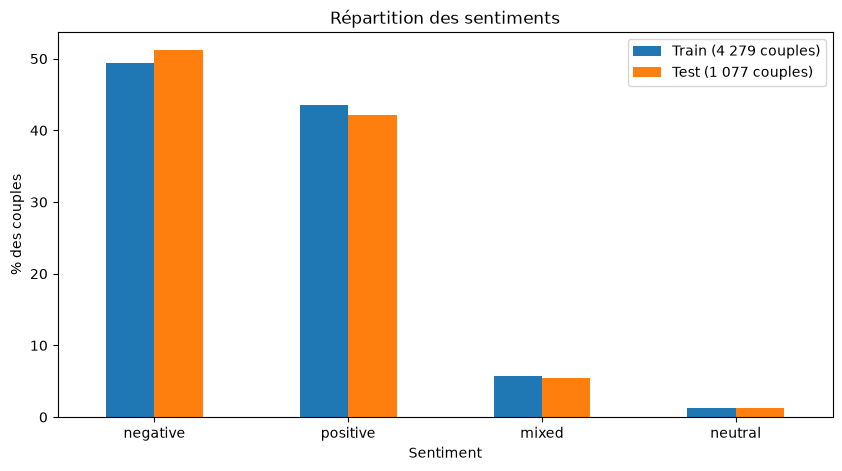

In [56]:
comparaison_sentiments[["% train", "% test"]].plot(kind="bar", figsize=(10, 5))

plt.title("Répartition des sentiments")
plt.xlabel("Sentiment")
plt.ylabel("% des couples")
plt.xticks(rotation=0)
plt.legend(["Train (4 279 couples)", "Test (1 077 couples)"])
plt.show()

In [23]:
# Vérifier que chaque annotation possède un sentiment
print("Sentiments manquants — TRAIN :", train_sentiment["sentiment"].isna().sum())
print("Sentiments manquants — TEST :", test_sentiment["sentiment"].isna().sum())

Sentiments manquants — TRAIN : 0
Sentiments manquants — TEST : 0


### Analyse de la répartition des sentiments

Le jeu d'entraînement contient **4 279 couples avis–aspect**, contre **1 077** dans le jeu de test. Ces effectifs correspondent aux annotations de sentiment, et non au nombre d'avis distincts.

La cible est fortement déséquilibrée :

- `negative` représente environ **49 % du train** et **51 % du test** ;
- `positive` représente environ **44 % du train** et **42 % du test** ;
- `mixed` représente moins de **6 %** de chaque ensemble ;
- `neutral` représente environ **1 %** de chaque ensemble.

Les proportions sont proches entre entraînement et test : l'écart maximal observé est de **1,83 point de pourcentage**, pour `negative`. Le découpage ne présente donc pas de différence majeure dans la répartition globale des sentiments.

Cette proximité ne supprime cependant pas le déséquilibre entre les classes. La classe `neutral` ne compte que **57 exemples d'entraînement**, ce qui peut limiter son apprentissage. Ses **13 exemples de test** rendent également son évaluation sensible à quelques prédictions.

Nous retiendrons le **Macro-F1** comme métrique principale afin de donner le même poids aux quatre classes. L'accuracy et le F1 par classe compléteront l'analyse.

Cette comparaison porte sur l'ensemble des annotations : elle ne suffit pas à vérifier la répartition des sentiments pour chaque aspect ou séparément dans GOLD et SILVER.

## Représentation TF-IDF

Les entrées `aspect + texte_complet` sont transformées en représentations numériques avec TF-IDF.

Nous conservons les paramètres utilisés pour la détection des aspects :

- `lowercase=True` : conversion en minuscules ;
- `ngram_range=(1, 2)` : prise en compte des mots seuls et des groupes de deux mots ;
- `min_df=2` : conservation des termes présents dans au moins deux entrées d'entraînement ;
- `max_features=20000` : limitation à 20 000 variables au maximum.

Il s'agit d'un nouveau vectoriseur, propre à la tâche sentiment. Son vocabulaire et ses poids IDF sont appris sur `X_train`, puis appliqués à `X_test` sans nouvel apprentissage.

Ce vectoriseur sera commun aux trois modèles de sentiment : régression logistique, SVM et XGBoost.

In [30]:
# Initialiser le vectoriseur pour les entrées aspect + texte
tfidf = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, max_features=20000)

# Apprendre le vocabulaire et les poids IDF sur l'entraînement
X_train_tfidf = tfidf.fit_transform(X_train)

# Transformer le test avec la même représentation
X_test_tfidf = tfidf.transform(X_test)

print("TRAIN TF-IDF :", X_train_tfidf.shape)
print("TEST TF-IDF :", X_test_tfidf.shape)

TRAIN TF-IDF : (4279, 20000)
TEST TF-IDF : (1077, 20000)


### Sauvegarde du vectoriseur de sentiment

Le vectoriseur appris est enregistré pour transformer ultérieurement de nouveaux couples avis–aspect.

Le fichier `tfidf_sentiments.joblib` est distinct de `tfidf_aspects.joblib`, utilisé pour la détection des aspects.

In [31]:
import os
import joblib

# Créer le dossier de sauvegarde si nécessaire
os.makedirs("../models", exist_ok=True)

# Enregistrer le vectoriseur propre à la tâche sentiment
joblib.dump(tfidf, "../models/tfidf_sentiments.joblib")

print("Vectoriseur TF-IDF des sentiments enregistré.")

Vectoriseur TF-IDF des sentiments enregistré.


### Résultat de la vectorisation

Après vectorisation :

- les **4 279 couples avis–aspect d'entraînement** sont représentés par une matrice de taille `(4279, 20000)` ;
- les **1 077 couples avis–aspect de test** sont représentés par une matrice de taille `(1077, 20000)`.

La limite fixée par `max_features=20000` est atteinte : chaque entrée est représentée par **20 000 variables TF-IDF**, correspondant à des mots ou à des groupes de deux mots.

Les deux matrices utilisent les mêmes variables, dans le même ordre. Le vocabulaire et les poids IDF ont été appris uniquement sur les entrées d'entraînement, puis appliqués au test.

Ces lignes correspondent à des couples avis–aspect : un même avis peut donc être représenté sur plusieurs lignes.

### Référence naïve : DummyClassifier

Avant d'entraîner les modèles sur le texte, nous construisons une référence naïve.

Le `DummyClassifier` ne tient pas compte des mots des avis. Avec la stratégie `most_frequent`, il prédit toujours le sentiment le plus fréquent dans le jeu d'entraînement.

Dans notre cas, il prédit donc toujours `negative`.

Cette référence fournit un plancher de performance. Elle permet de vérifier que les modèles utilisant le TF-IDF apportent réellement une amélioration.

Nous utiliserons les mêmes métriques que pour les autres modèles :

- Accuracy ;
- Macro-F1 ;
- Weighted-F1.

In [62]:
from sklearn.dummy import DummyClassifier

# Toujours prédire la classe la plus fréquente dans le train
modele_dummy = DummyClassifier(strategy="most_frequent")

# Identifier cette classe à partir des labels d'entraînement
modele_dummy.fit(X_train_tfidf, y_train)

# Prédire le même sentiment pour tous les couples avis–aspect du test
y_pred_dummy = modele_dummy.predict(X_test_tfidf)

# Évaluer avec les mêmes métriques que les autres modèles
print("Accuracy dummy :", round(accuracy_score(y_test, 
                                               y_pred_dummy), 3))

print("Macro-F1 dummy :", round(f1_score(y_test, 
                                         y_pred_dummy, 
                                         average="macro", 
                                         zero_division=0), 3))

print("Weighted-F1 dummy :", round(f1_score(y_test, 
                                            y_pred_dummy, 
                                            average="weighted", 
                                            zero_division=0), 3))

Accuracy dummy : 0.512
Macro-F1 dummy : 0.169
Weighted-F1 dummy : 0.346


### Résultats du modèle de référence naïf

Le `DummyClassifier` obtient :

- **Accuracy : 0,512** ;
- **Macro-F1 : 0,169** ;
- **Weighted-F1 : 0,346**.

L'Accuracy de **0,512** correspond à la proportion de couples avis–aspect annotés `negative` dans le jeu de test : **551 sur 1 077**.

Le dummy obtient un score non nul uniquement pour `negative`, puisqu'il prédit toujours cette classe. Les trois autres sentiments (`positive`, `mixed` et `neutral`) ne sont jamais prédits correctement.

Le **Macro-F1 de 0,169** reste donc très faible : il fait la moyenne des F1 des quatre classes et attribue le score zéro aux classes qui ne sont pas prédites.

Le **Weighted-F1 de 0,346** est supérieur au Macro-F1 car il pondère les scores par les effectifs. Il reste toutefois faible, puisque le dummy ne tient pas compte du contenu des avis.

Cette référence représente le niveau de performance obtenu sans exploiter le texte. Les modèles TF-IDF seront comparés à ce plancher.

## Etapes : 
- Entraîner LR, SVM et XGBoost sur le train;
- Comparer leurs scores sur le test;
- Choisir la LR à optimiser à partir de cette comparaison;
- Optimiser son paramètre C sur le train avec GroupKFold;
- Évaluer la LR optimisée sur le test;
- Analyser les erreurs avec les résultats par sentiment et la matrice de confusion;
- Sauvegarder le modèle et son TF-IDF pour analyser de nouveaux couples avis–aspect sans réentraîner.

## Régression logistique

Nous entraînons une régression logistique pour prédire le sentiment de chaque couple avis–aspect parmi quatre classes : `negative`, `positive`, `mixed` et `neutral`.

Contrairement au notebook aspects, chaque ligne possède ici une seule classe à prédire. Nous utilisons directement `LogisticRegression`, sans ajouter `OneVsRestClassifier`.

Le paramètre `class_weight="balanced"` donne davantage de poids aux exemples des classes peu représentées pendant l'entraînement.

Nous évaluons le modèle avec :

- **Accuracy** : proportion de couples avis–aspect correctement classés ;
- **Macro-F1** : moyenne des F1 des quatre classes, avec le même poids pour chacune ;
- **Weighted-F1** : moyenne des F1 pondérée par les effectifs des classes dans le test.

Le Macro-F1 est notre métrique principale. Le rapport par classe permettra d'examiner les difficultés sur `mixed` et `neutral`.

In [32]:
# Créer le modèle en tenant compte du déséquilibre des sentiments
modele_lr = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)

# Entraîner le modèle sur les couples avis–aspect vectorisés
modele_lr.fit(X_train_tfidf, y_train)

# Prédire le sentiment des couples avis–aspect du test
y_pred_lr = modele_lr.predict(X_test_tfidf)

# Afficher les performances globales
print("Accuracy :", round(accuracy_score(y_test, y_pred_lr), 3))
print("Macro-F1 :", round(f1_score(y_test, y_pred_lr, average="macro"), 3))
print("Weighted-F1 :", round(f1_score(y_test, y_pred_lr, average="weighted"), 3))

# Examiner la précision, le rappel et le F1 de chaque sentiment
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_lr, zero_division=0))

Accuracy : 0.758
Macro-F1 : 0.436
Weighted-F1 : 0.758

Rapport de classification :
              precision    recall  f1-score   support

       mixed       0.12      0.15      0.13        59
    negative       0.80      0.83      0.81       551
     neutral       0.00      0.00      0.00        13
    positive       0.82      0.78      0.80       454

    accuracy                           0.76      1077
   macro avg       0.43      0.44      0.44      1077
weighted avg       0.76      0.76      0.76      1077



In [33]:
# Enregistrer le modèle entraîné, associé à tfidf_sentiments.joblib
joblib.dump(modele_lr, "../models/modele_lr_sentiments.joblib")

print("Modèle LR initial de sentiment enregistré.")

Modèle LR initial de sentiment enregistré.


### Résultats de la régression logistique

La régression logistique obtient :

- **Accuracy : 0,758** ;
- **Macro-F1 : 0,436** ;
- **Weighted-F1 : 0,758**.

Environ **75,8 % des 1 077 couples avis–aspect du test** sont correctement classés. Les performances varient cependant fortement selon le sentiment.

Les classes majoritaires sont les mieux reconnues :

- `negative` : F1 de **0,81**, avec un rappel de **0,83** ;
- `positive` : F1 de **0,80**, avec un rappel de **0,78**.

Les résultats sont nettement plus faibles pour les classes minoritaires :

- `mixed` : F1 de **0,13**. Le rappel de **0,15** indique que peu d'exemples annotés `mixed` sont retrouvés. La précision de **0,12** montre également que les prédictions de cette classe sont souvent incorrectes ;
- `neutral` : aucune détection correcte parmi les **13 exemples du test**.

L'écart entre le Weighted-F1 (**0,758**) et le Macro-F1 (**0,436**) reflète ces différences : les bons résultats sur les classes fréquentes dominent la moyenne pondérée, tandis que le Macro-F1 donne autant de poids aux difficultés sur `mixed` et `neutral`.

La pondération `class_weight="balanced"` ne suffit donc pas, dans cette configuration, à obtenir de bonnes performances sur les quatre sentiments. Le faible support de `neutral` rend aussi son évaluation sensible à quelques prédictions.

Cette première baseline servira de référence pour comparer le SVM et XGBoost.


## Deuxième baseline : SVM linéaire

Nous entraînons un SVM linéaire avec `LinearSVC` pour prédire les quatre classes de sentiment.

Les matrices TF-IDF et le découpage entraînement/test sont identiques à ceux utilisés pour la régression logistique. Le vectoriseur n'est pas réentraîné.

Le paramètre `class_weight="balanced"` est conservé pour tenir compte du déséquilibre des classes.

Nous utilisons les mêmes métriques : Accuracy, Macro-F1 et Weighted-F1, ainsi que le rapport de classification par sentiment.

In [36]:
# si on veux recherger le victoriseur et l'utilser
# Recharger le vectoriseur déjà appris
# tfidf = joblib.load("../models/tfidf_sentiments.joblib")

# Transformer les textes avec ce vectoriseur
# X_train_tfidf = tfidf.transform(X_train)
# X_test_tfidf = tfidf.transform(X_test)

In [34]:
# Créer le SVM linéaire en tenant compte du déséquilibre des classes
modele_svm = LinearSVC(class_weight="balanced", max_iter=5000, random_state=42)

# Entraîner le modèle sur les mêmes données TF-IDF que la LR
modele_svm.fit(X_train_tfidf, y_train)

# Prédire un sentiment pour chaque couple avis–aspect du test
y_pred_svm = modele_svm.predict(X_test_tfidf)

# Afficher les performances globales
print("Accuracy :", round(accuracy_score(y_test, y_pred_svm), 3))
print("Macro-F1 :", round(f1_score(y_test, y_pred_svm, average="macro"), 3))
print("Weighted-F1 :", round(f1_score(y_test, y_pred_svm, average="weighted"), 3))

# Examiner les performances pour chaque sentiment
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_svm, zero_division=0))

Accuracy : 0.784
Macro-F1 : 0.431
Weighted-F1 : 0.768

Rapport de classification :
              precision    recall  f1-score   support

       mixed       0.15      0.07      0.09        59
    negative       0.79      0.88      0.83       551
     neutral       0.00      0.00      0.00        13
    positive       0.82      0.78      0.80       454

    accuracy                           0.78      1077
   macro avg       0.44      0.43      0.43      1077
weighted avg       0.76      0.78      0.77      1077



In [35]:
# Enregistrer le SVM entraîné, associé à tfidf_sentiments.joblib
joblib.dump(modele_svm, "../models/modele_svm_sentiments.joblib")

print("Modèle SVM de sentiment enregistré.")

Modèle SVM de sentiment enregistré.


### Résultats du SVM linéaire

Le SVM obtient :

- **Accuracy : 0,784** ;
- **Macro-F1 : 0,431** ;
- **Weighted-F1 : 0,768**.

Par rapport à la régression logistique, l'Accuracy augmente de **0,758 à 0,784** et le Weighted-F1 de **0,758 à 0,768**. Le Macro-F1 diminue légèrement, de **0,436 à 0,431**.

L'analyse par sentiment montre que :

- `negative` est mieux reconnu : son rappel passe de **0,83 à 0,88** et son F1 de **0,81 à 0,83** ;
- `positive` conserve les mêmes scores aux arrondis affichés, avec un F1 de **0,80** ;
- `mixed` est moins bien détecté : son rappel passe de **0,15 à 0,07** et son F1 de **0,13 à 0,09** ;
- `neutral` ne compte toujours aucune détection correcte parmi les **13 exemples du test**.

Le gain du SVM concerne donc principalement la classe majoritaire `negative`. Il ne résout pas les difficultés observées sur les sentiments minoritaires.

À ce stade, la régression logistique conserve un léger avantage selon le Macro-F1, notre métrique principale. Cette comparaison concerne uniquement les configurations initiales évaluées sur ce jeu de test.

## Troisième baseline : XGBoost

Nous entraînons XGBoost sur les mêmes matrices TF-IDF que la régression logistique et le SVM.

Les sentiments sont convertis en codes numériques :

- `mixed` : 0 ;
- `negative` : 1 ;
- `neutral` : 2 ;
- `positive` : 3.

Ces nombres identifient les classes : ils ne représentent pas un ordre entre les sentiments.

Le paramètre `objective="multi:softmax"` correspond à une classification multiclasse, et `num_class=4` indique le nombre de classes.

Cette configuration initiale ne comporte pas de pondération explicite des classes, contrairement à la régression logistique et au SVM. Cette différence sera prise en compte dans la comparaison.

In [37]:
# Associer chaque sentiment à un code numérique
mapping_sentiment = {"mixed": 0, "negative": 1, "neutral": 2, "positive": 3}

# Convertir les cibles sans modifier y_train et y_test
y_train_xgb = y_train.map(mapping_sentiment)
y_test_xgb = y_test.map(mapping_sentiment)

# Créer le modèle XGBoost pour les quatre sentiments
modele_xgb = XGBClassifier(n_estimators=100, learning_rate=0.3, max_depth=6, 
                           objective="multi:softmax", num_class=4, eval_metric="mlogloss",
                           random_state=42)

# Entraîner le modèle sur les mêmes matrices TF-IDF
modele_xgb.fit(X_train_tfidf, y_train_xgb)

# Prédire les sentiments sous forme de codes numériques
y_pred_xgb = modele_xgb.predict(X_test_tfidf)

# Comparer les prédictions aux cibles également codées
print("Accuracy :", round(accuracy_score(y_test_xgb, y_pred_xgb), 3))
print("Macro-F1 :", round(f1_score(y_test_xgb, y_pred_xgb, average="macro"), 3))
print("Weighted-F1 :", round(f1_score(y_test_xgb, y_pred_xgb, average="weighted"), 3))

# Afficher les noms des sentiments dans l'ordre de leurs codes
print("\nRapport de classification :")
print(classification_report(y_test_xgb,y_pred_xgb,labels=[0, 1, 2, 3],
                            target_names=["mixed", "negative", "neutral", "positive"],zero_division=0))

Accuracy : 0.773
Macro-F1 : 0.407
Weighted-F1 : 0.75

Rapport de classification :
              precision    recall  f1-score   support

       mixed       0.11      0.02      0.03        59
    negative       0.78      0.87      0.82       551
     neutral       0.00      0.00      0.00        13
    positive       0.78      0.78      0.78       454

    accuracy                           0.77      1077
   macro avg       0.42      0.42      0.41      1077
weighted avg       0.73      0.77      0.75      1077



In [38]:
# Enregistrer le modèle et la correspondance entre sentiments et codes
joblib.dump(modele_xgb, "../models/modele_xgb_sentiments.joblib")
joblib.dump(mapping_sentiment, "../models/mapping_sentiment.joblib")

print("Modèle XGBoost et correspondance des sentiments enregistrés.")

Modèle XGBoost et correspondance des sentiments enregistrés.


### Résultats de XGBoost

XGBoost obtient :

- **Accuracy : 0,773** ;
- **Macro-F1 : 0,407** ;
- **Weighted-F1 : 0,750**.

Les performances sont principalement portées par les classes majoritaires :

- `negative` : F1 de **0,82**, avec un rappel de **0,87** ;
- `positive` : F1 de **0,78**, avec une précision et un rappel de **0,78**.

Les difficultés persistent sur les classes minoritaires :

- `mixed` : F1 de **0,03** et rappel de **0,02**, ce qui indique que très peu des 59 exemples sont correctement détectés ;
- `neutral` : aucune détection correcte parmi les **13 exemples du test**.

Le Macro-F1 de XGBoost (**0,407**) est inférieur à celui de la régression logistique (**0,436**) et du SVM (**0,431**). Cette configuration n'améliore donc pas la moyenne des performances sur les quatre sentiments.

La comparaison doit toutefois tenir compte d'une différence : la régression logistique et le SVM utilisent `class_weight="balanced"`, tandis que cette baseline XGBoost n'applique aucune pondération explicite des classes.

Ces résultats concernent les configurations initiales testées ; ils ne permettent pas de conclure à une infériorité générale de XGBoost.

## Comparaison des modèles initiaux et du DummyClassifier

Les trois modèles entraînés sur les textes et le `DummyClassifier` sont évalués sur les mêmes couples avis–aspect du jeu de test.

Le `DummyClassifier` sert de référence naïve : il ne tient pas compte du texte et prédit toujours la classe la plus fréquente, `negative`.

Le Macro-F1 constitue notre critère principal, car il donne le même poids aux quatre sentiments. L'Accuracy et le Weighted-F1 complètent cette comparaison.

Cette comparaison permet de mesurer l'apport réel des modèles utilisant les représentations TF-IDF par rapport à une prédiction sans analyse du texte.

In [67]:
# Regrouper les scores des trois modèles
comparaison_modeles = pd.DataFrame({"Modèle": ["DummyClassifier", 
                                               "Régression logistique",
                                               "SVM", "XGBoost"],
                                    "Accuracy": [accuracy_score(y_test, y_pred_dummy),
                                                 accuracy_score(y_test, y_pred_lr),
                                                 accuracy_score(y_test, y_pred_svm),
                                                 accuracy_score(y_test_xgb, y_pred_xgb)],
                                    "Macro-F1": [f1_score(y_test, y_pred_dummy, average="macro", zero_division=0),
                                                 f1_score(y_test, y_pred_lr, average="macro"),
                                                 f1_score(y_test, y_pred_svm, average="macro"),
                                                 f1_score(y_test_xgb, y_pred_xgb, average="macro")],
                                 "Weighted-F1": [f1_score(y_test, y_pred_dummy, average="weighted", zero_division=0), 
                                                 f1_score(y_test, y_pred_lr, average="weighted"),
                                                 f1_score(y_test, y_pred_svm, average="weighted"),
                                                 f1_score(y_test_xgb, y_pred_xgb, average="weighted")]})

# Arrondir uniquement pour l'affichage
display(comparaison_modeles.round(3))

,Modèle,Accuracy,Macro-F1,Weighted-F1
0,DummyClassifier,0.512,0.169,0.346
1,Régression logistique,0.758,0.436,0.758
2,SVM,0.784,0.431,0.768
3,XGBoost,0.773,0.407,0.750


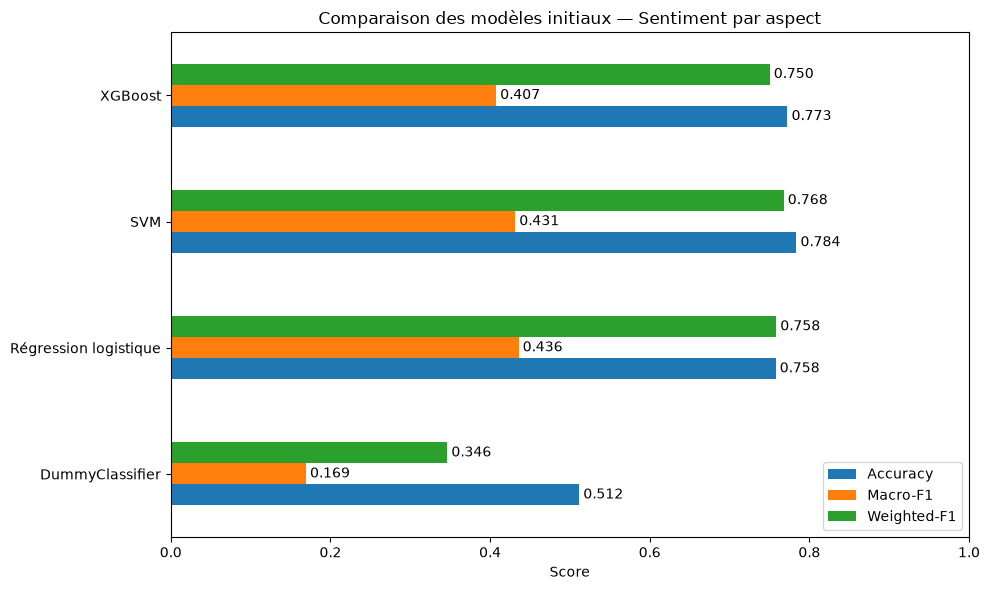

In [68]:
# Représenter les scores du tableau comparatif
# Les noms des modèles deviennent les étiquettes des barres
ax = comparaison_modeles.set_index("Modèle").plot(kind="barh",
                                                  figsize=(10, 6))

plt.title("Comparaison des modèles initiaux — Sentiment par aspect")
plt.xlabel("Score")
plt.ylabel("")

# Les trois métriques prennent des valeurs entre 0 et 1
plt.xlim(0, 1)

# Afficher les valeurs à côté des barres
for barres in ax.containers:
    ax.bar_label(barres, fmt="%.3f", padding=3)

plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Comparaison des modèles initiaux et du DummyClassifier

Les trois modèles entraînés sur le texte et le `DummyClassifier` sont évalués sur les mêmes couples avis–aspect du jeu de test.

Le `DummyClassifier` sert de référence naïve. Il ne tient pas compte du contenu des avis et prédit toujours le sentiment le plus fréquent dans le jeu d'entraînement, ici `negative`.

Le SVM obtient la meilleure Accuracy (**0,784**) et le meilleur Weighted-F1 (**0,768**). Ces scores sont cependant fortement influencés par les classes majoritaires.

La régression logistique obtient le meilleur Macro-F1 (**0,436**), devant le SVM (**0,431**) et XGBoost (**0,407**). Son avantage sur le SVM reste faible : **0,005**.

Les trois modèles entraînés sur les textes dépassent nettement le DummyClassifier. Celui-ci obtient une Accuracy de **0,512**, un Macro-F1 de **0,169** et un Weighted-F1 de **0,346**, sans exploiter le contenu des avis.

Par rapport au dummy, la régression logistique apporte un gain de **24,6 points d’accuracy** (0,758 contre 0,512) et de **0,267 en Macro-F1** (0,436 contre 0,169).

Les rapports par classe montrent que les modèles rencontrent encore des difficultés sur `mixed` et `neutral`. La comparaison avec le dummy montre toutefois que les modèles TF-IDF apportent une information utile par rapport à une prédiction fondée uniquement sur la classe majoritaire.

Le Macro-F1 étant notre métrique principale, la régression logistique est retenue comme candidate pour l'optimisation. Cette décision est fondée sur la comparaison descriptive des configurations initiales ; la recherche de ses hyperparamètres est ensuite réalisée uniquement sur le jeu d'entraînement avec `GroupKFold`.

Ces résultats concernent les configurations initiales. La pondération des classes diffère également : elle est activée pour la régression logistique et le SVM, mais pas pour cette configuration de XGBoost.

### Choix du modèle à optimiser

La régression logistique est retenue pour l’optimisation car elle obtient le meilleur Macro-F1 parmi les configurations initiales : **0,436**, contre **0,431** pour le SVM et **0,407** pour XGBoost.

Son avantage en Macro-F1 sur le SVM reste faible. Ce choix permet de concentrer l'optimisation sur une candidate ; il ne démontre pas une supériorité générale de la régression logistique.

Ce choix s’appuie sur les résultats du jeu de test, ce qui constitue une limite du protocole : le test intervient donc dans la sélection du modèle.

La recherche du paramètre `C` est ensuite réalisée uniquement sur le jeu d’entraînement, avec une validation croisée GroupKFold regroupant les lignes par `review_id`.


## Optimisation de la régression logistique

Nous testons plusieurs valeurs de `C`, qui contrôle la régularisation :

- une petite valeur renforce la régularisation ;
- une grande valeur la réduit.

La meilleure valeur est sélectionnée selon le Macro-F1 moyen en validation croisée à cinq plis, uniquement sur les données d'entraînement.

Comme plusieurs lignes peuvent correspondre au même avis, nous utilisons `GroupKFold` avec le `review_id` comme groupe. Toutes les annotations d'un avis restent ainsi ensemble dans chaque découpage.

Le TF-IDF reste celui appris précédemment sur l'ensemble du train. Cette simplification conserve une limite : les textes des plis de validation ont participé à la construction du vocabulaire et des poids IDF.

In [42]:
# Tester plusieurs niveaux de régularisation
param_grid_lr = {"C": [0.01, 0.1, 1, 10]}

# Construire cinq plis en gardant ensemble les lignes d'un même avis
cv = GroupKFold(n_splits=5)

# Rechercher la valeur de C obtenant le meilleur Macro-F1 moyen
grid_lr = GridSearchCV(LogisticRegression(max_iter=2000,class_weight="balanced",random_state=42),
                       param_grid=param_grid_lr, cv=cv, scoring="f1_macro", n_jobs=-1, refit=True)

# Fournir les identifiants des avis pour organiser les plis
grid_lr.fit(X_train_tfidf, y_train, groups=train_sentiment["review_id"])

print("Meilleurs paramètres :", grid_lr.best_params_)
print("Meilleur Macro-F1 CV :", round(grid_lr.best_score_, 3))

Meilleurs paramètres : {'C': 1}
Meilleur Macro-F1 CV : 0.44


In [43]:
# Récupérer le meilleur modèle déjà entraîné
modele_lr_opt = grid_lr.best_estimator_

# Conserver les paramètres et les résultats de la recherche
joblib.dump(grid_lr, "../models/grid_lr_sentiments.joblib")

# Enregistrer le modèle associé à tfidf_sentiments.joblib
joblib.dump(modele_lr_opt, "../models/modele_lr_opt_sentiments.joblib")

print("Recherche et modèle LR de sentiment enregistrés.")

Recherche et modèle LR de sentiment enregistrés.


### Résultat de la recherche d'hyperparamètres

Parmi les valeurs testées (`0.01`, `0.1`, `1`, `10`), la validation croisée sélectionne **C = 1**, avec un **Macro-F1 moyen de 0,440**.

Cette valeur correspond à celle utilisée par la régression logistique initiale. La recherche ne conduit donc pas à modifier sa configuration.

La validation croisée a conservé toutes les lignes d'un même avis dans le même pli grâce au regroupement par `review_id`.

Le score de **0,440** correspond aux plis de validation du jeu d'entraînement. Il ne doit pas être confondu avec le Macro-F1 de **0,436** obtenu précédemment sur le jeu de test.

In [44]:
# Prédire les sentiments du test avec le modèle retenu
y_pred_lr_opt = modele_lr_opt.predict(X_test_tfidf)

# Afficher les performances globales
print("Accuracy :", round(accuracy_score(y_test, y_pred_lr_opt), 3))
print("Macro-F1 :", round(
    f1_score(y_test, y_pred_lr_opt, average="macro"), 3
))
print("Weighted-F1 :", round(
    f1_score(y_test, y_pred_lr_opt, average="weighted"), 3
))

# Examiner les performances pour chaque sentiment
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_lr_opt, zero_division=0))

Accuracy : 0.758
Macro-F1 : 0.436
Weighted-F1 : 0.758

Rapport de classification :
              precision    recall  f1-score   support

       mixed       0.12      0.15      0.13        59
    negative       0.80      0.83      0.81       551
     neutral       0.00      0.00      0.00        13
    positive       0.82      0.78      0.80       454

    accuracy                           0.76      1077
   macro avg       0.43      0.44      0.44      1077
weighted avg       0.76      0.76      0.76      1077



### Évaluation après optimisation

Les scores sur le jeu de test sont identiques à ceux de la régression logistique initiale :

- **Accuracy : 0,758** ;
- **Macro-F1 : 0,436** ;
- **Weighted-F1 : 0,758**.

La recherche a retenu `C = 1`, valeur déjà utilisée dans la baseline. Dans la grille testée, l'optimisation n'apporte donc aucune amélioration des scores affichés.

Les difficultés restent les mêmes : les sentiments `negative` et `positive` sont les mieux reconnus, tandis que `mixed` obtient un F1 de **0,13** et qu'aucun exemple `neutral` n'est correctement détecté.

Une matrice de confusion permettra maintenant d'identifier vers quelles classes les exemples mal classés sont orientés.

### Matrice de confusion

La matrice compare les sentiments annotés aux sentiments prédits :

- les lignes correspondent aux classes réelles ;
- les colonnes correspondent aux classes prédites ;
- la diagonale contient les prédictions correctes ;
- les autres cellules représentent les erreurs.

Les effectifs correspondent à des couples avis–aspect, et non à des avis distincts.

In [45]:
# Compter les croisements entre sentiments réels et prédits
matrice_lr = pd.crosstab(y_test, y_pred_lr_opt, 
                         rownames=["Classe réelle"],colnames=["Classe prédite"])

# Afficher la matrice de confusion
display(matrice_lr)

Classe prédite,mixed,negative,neutral,positive
Classe réelle,,,,
mixed,9,30,1,19
negative,42,455,1,53
neutral,0,8,0,5
positive,24,78,0,352


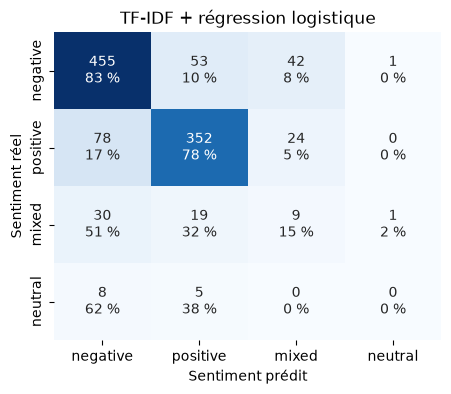

In [61]:
labels = ["negative", "positive", "mixed", "neutral"]

# Matrice de confusion LR
matrice_lr = pd.crosstab(y_test,y_pred_lr_opt,rownames=["Classe réelle"],colnames=["Classe prédite"]
                        ).reindex(index=labels, columns=labels, fill_value=0)

# Pourcentages par ligne
matrice_lr_pct = matrice_lr.div(matrice_lr.sum(axis=1), axis=0) * 100

# Texte dans les cases
annotations_lr = matrice_lr.astype(str) + "\n" + matrice_lr_pct.round(0).astype(int).astype(str) + " %"

plt.figure(figsize=(5, 4))
sns.heatmap(matrice_lr, annot=annotations_lr, fmt="", cmap="Blues", cbar=False)

plt.title("TF-IDF + régression logistique")
plt.xlabel("Sentiment prédit")
plt.ylabel("Sentiment réel")
plt.show()

### Analyse de la matrice de confusion

La matrice confirme que le modèle reconnaît mieux les deux sentiments majoritaires :

- `negative` : **455 couples avis–aspect sur 551** sont correctement classés ;
- `positive` : **352 sur 454** sont correctement classés.

Des confusions existent entre ces deux sentiments : **53 exemples négatifs** sont prédits positifs et **78 exemples positifs** sont prédits négatifs.

La classe `mixed` reste difficile à reconnaître. Sur **59 exemples**, seuls **9** sont correctement classés. Les autres sont principalement prédits `negative` (**30 cas**) ou `positive` (**19 cas**).

Le modèle prédit également `mixed` pour **42 exemples négatifs** et **24 exemples positifs**. Il produit ainsi **75 prédictions `mixed`**, dont seulement **9 correctes**, ce qui explique la faible précision de cette classe.

Pour `neutral`, aucun des **13 exemples** n'est correctement détecté : **8** sont prédits négatifs et **5** positifs. Le modèle ne prédit cette classe que **deux fois**, dans les deux cas à tort.

Ces résultats montrent que cette représentation TF-IDF associée à la régression logistique distingue mieux les sentiments positifs et négatifs que les sentiments mixtes ou neutres. La matrice décrit les erreurs, mais ne permet pas, à elle seule, d'en déterminer les causes.

## Analyse d'un nouvel avis : aspects et sentiments

L'analyse se déroule en deux étapes :

1. Le modèle d'aspects détecte les aspects présents dans l'avis.
2. Pour chaque aspect détecté, le modèle de sentiment reçoit l'entrée `aspect + texte_complet` et prédit un sentiment.

Chaque modèle utilise son propre vectoriseur TF-IDF, appris lors de son entraînement.

Si aucun aspect n'est détecté, le résultat est un tableau vide. Cet exemple illustre le fonctionnement des deux modèles ensemble ; il ne remplace pas leur évaluation sur le jeu de test.

In [46]:
# Recharger le modèle d'aspects, son vectoriseur et l'ordre de ses sorties
aspects_ml = {"tfidf": joblib.load("../models/tfidf_aspects.joblib"),
              "modele": joblib.load("../models/modele_lr_opt_aspects.joblib"),
              "aspects": joblib.load("../models/liste_aspects.joblib")}

# Recharger le modèle de sentiment et son propre vectoriseur
sentiments_ml = {"tfidf": joblib.load("../models/tfidf_sentiments.joblib"),
                 "modele": joblib.load("../models/modele_lr_opt_sentiments.joblib")}

In [47]:
def analyser_avis_ml(texte):
    # Transformer l'avis avec le TF-IDF du modèle d'aspects
    texte_tfidf = aspects_ml["tfidf"].transform([texte])
    prediction = aspects_ml["modele"].predict(texte_tfidf)[0]

    # Récupérer les aspects prédits comme présents
    aspects_detectes = [aspect
        for aspect, valeur in zip(aspects_ml["aspects"], prediction)
        if valeur == 1]

    resultats = []

    for aspect in aspects_detectes:
        # Construire la même entrée que pendant l'entraînement sentiment
        texte_aspect = aspect + " " + texte

        # Utiliser le TF-IDF et le modèle propres aux sentiments
        texte_tfidf = sentiments_ml["tfidf"].transform([texte_aspect])
        sentiment = sentiments_ml["modele"].predict(texte_tfidf)[0]

        resultats.append({"aspect": aspect,"sentiment": sentiment})

    return pd.DataFrame(resultats, columns=["aspect", "sentiment"])

In [50]:

avis_test = ("The delivery was very late, but the customer service was excellent and very helpful.")

display(analyser_avis_ml(avis_test))

,aspect,sentiment
0,customer service,positive
1,delivery,positive
2,staff,positive


### Analyse de la prédiction sur un nouvel avis

L'avis testé exprime un sentiment négatif sur la livraison et positif sur le service client.

| Aspect retourné | Sentiment prédit | Interprétation |
|---|---|---|
| `customer service` | `positive` | Aspect et sentiment correctement identifiés |
| `delivery` | `positive` | Aspect correctement détecté, mais sentiment incorrect : « very late » exprime ici une appréciation négative |
| `staff` | `positive` | Aspect supplémentaire, non explicitement mentionné ; sa pertinence dépend des règles d'annotation distinguant le personnel du service client |

Cet exemple met en évidence les limites des deux étapes : la détection peut ajouter un aspect, et le modèle de sentiment peut attribuer une mauvaise polarité à un aspect correctement détecté.

Pour chaque aspect, le modèle de sentiment reçoit le texte complet de l'avis, précédé du nom de l'aspect. Les expressions positives « excellent » et « very helpful » restent donc présentes même lorsque l'aspect ciblé est `delivery`. Il n'a donc pas correctement distingué les sentiments associés aux deux aspects dans cet exemple.

Une explication possible est que le modèle s'appuie davantage sur ces expressions positives que sur leur association au service client. Cet exemple seul ne permet toutefois pas de confirmer cette explication.

La construction `aspect + texte_complet` fournit une baseline simple, mais ne garantit pas que le modèle distingue correctement les sentiments de plusieurs aspects dans un même avis.

### Conclusion

La régression logistique est retenue pour la prédiction du sentiment associé à chaque aspect. L’optimisation par validation croisée GroupKFold sélectionne `C=1`, déjà utilisé dans la configuration initiale : elle n’améliore donc pas les performances.

Sur le jeu de test, le modèle obtient une **accuracy de 0,758**, un **Macro-F1 de 0,436** et un **Weighted-F1 de 0,758**.

Les sentiments `negative` et `positive` sont les mieux reconnus.
En revanche, `mixed` reste difficile à identifier et aucun des **13 exemples `neutral`** du test n’est correctement classé.

Le modèle dépasse la référence naïve, mais ses performances restent inégales selon les sentiments. L’exemple final montre également une difficulté à associer chaque sentiment au bon aspect lorsque plusieurs opinions sont exprimées dans un même avis.

1. Objectif : sentiment par aspect

2. Préparation du dataset: review_id, texte_complet, aspect, sentiment

3. Conservation du split de la Tâche 1 review_id train → train_sentiment // review_id test  → test_sentiment

4. Analyse de la cible sentiment effectifs / déséquilibre des classes

5. Construction de l'entrée texte_complet + aspect

6. TF-IDF

8. DummyClassifier

9. Logistic Regression

10. SVM

11. XGBoost

12. Comparaison LR / SVM / XGBoost / DummyClassifier

13. Optimisation du meilleur

14. Évaluation détaillée: Precision / Recall / F1, matrice de confusion

16.  Conclusion Tâche 2

17. Prédiction sur un nouvel avis
